# Module 6 Assignment — Fashion MNIST Classification 

A 6-layer Convolutional Neural Network (CNN) built with Keras to classify the
[Fashion MNIST](https://keras.io/api/datasets/fashion_mnist/) dataset.

**Architecture (6 layers):**
1. `Conv2D` (32 filters, 3x3, ReLU)
2. `MaxPooling2D` (2x2)
3. `Conv2D` (64 filters, 3x3, ReLU)
4. `MaxPooling2D` (2x2)
5. `Flatten`
6. `Dense` (10 units, softmax)


## 1. Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Human-readable names for the 10 Fashion MNIST classes.
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

## 2. Classifier class

A class that wraps data loading, model building, training, evaluation, and prediction.

In [12]:
class FashionMNISTClassifier:
    """
    A six-layer CNN wrapper for loading, training, evaluating, and making
    predictions on the Fashion MNIST dataset.
    """

    def __init__(self, input_shape=(28, 28, 1), num_classes=10):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.history = None

        # Data placeholders, populated by load_data()
        self.x_train = self.y_train = None
        self.x_test = self.y_test = None

    # ------------------------------------------------------------------
    # Data
    # ------------------------------------------------------------------
    def load_data(self):
        """Load and preprocess the Fashion MNIST dataset."""
        (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

        # Normalize pixel values to [0, 1] and add the channel dimension
        # (28, 28) -> (28, 28, 1) since the images are grayscale.
        x_train = x_train.astype("float32") / 255.0
        x_test = x_test.astype("float32") / 255.0
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)

        self.x_train, self.y_train = x_train, y_train
        self.x_test, self.y_test = x_test, y_test

        print(f"Training data shape: {self.x_train.shape}")
        print(f"Test data shape:     {self.x_test.shape}")
        return (x_train, y_train), (x_test, y_test)

    # ------------------------------------------------------------------
    # Model
    # ------------------------------------------------------------------
    def _build_model(self):
        """Construct the six-layer CNN architecture."""
        model = keras.Sequential(
            [
                keras.Input(shape=self.input_shape),
                layers.Conv2D(32, kernel_size=3, activation="relu"),   # Layer 1
                layers.MaxPooling2D(pool_size=2),                      # Layer 2
                layers.Conv2D(64, kernel_size=3, activation="relu"),   # Layer 3
                layers.MaxPooling2D(pool_size=2),                      # Layer 4
                layers.Flatten(),                                      # Layer 5
                layers.Dense(self.num_classes, activation="softmax"),  # Layer 6
            ],
            name="fashion_mnist_cnn",
        )

        model.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        return model

    def summary(self):
        self.model.summary()

    # ------------------------------------------------------------------
    # Training / evaluation
    # ------------------------------------------------------------------
    def train(self, epochs=10, batch_size=128, validation_split=0.1):
        """Train the CNN on the training set."""
        if self.x_train is None:
            raise RuntimeError("Call load_data() before training.")

        self.history = self.model.fit(
            self.x_train,
            self.y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
        )
        return self.history

    def evaluate(self):
        """Evaluate the CNN on the held-out test set."""
        loss, accuracy = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        print(f"Test loss:     {loss:.4f}")
        print(f"Test accuracy: {accuracy:.4f}")
        return loss, accuracy

    # ------------------------------------------------------------------
    # Prediction
    # ------------------------------------------------------------------
    def predict(self, images):
        """Return predicted class indices for a batch of images."""
        probabilities = self.model.predict(images)
        return np.argmax(probabilities, axis=1)

    def predict_and_show(self, num_images=5):
        """
        Predict on `num_images` samples from the test set and display
        each image alongside its true and predicted label.
        """
        if self.x_test is None:
            raise RuntimeError("Call load_data() before predicting.")

        indices = np.random.choice(len(self.x_test), size=num_images, replace=False)
        sample_images = self.x_test[indices]
        true_labels = self.y_test[indices]
        predicted_labels = self.predict(sample_images)

        fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 3))
        if num_images == 1:
            axes = [axes]

        for ax, image, true_label, pred_label in zip(
            axes, sample_images, true_labels, predicted_labels
        ):
            ax.imshow(image.squeeze(), cmap="gray")
            title_color = "green" if true_label == pred_label else "red"
            ax.set_title(
                f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}",
                color=title_color,
                fontsize=10,
            )
            ax.axis("off")

        plt.tight_layout()
        plt.savefig("predictions.png", dpi=150)
        plt.show()

        for i, idx in enumerate(indices):
            print(
                f"Image {idx}: true label = {CLASS_NAMES[true_labels[i]]}, "
                f"predicted label = {CLASS_NAMES[predicted_labels[i]]}"
            )

## 3. Instantiate the model and view the architecture

In [13]:
classifier = FashionMNISTClassifier()
classifier.summary()

Model: "fashion_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Load the data

In [14]:
(x_train, y_train), (x_test, y_test) = classifier.load_data()

Training data shape: (60000, 28, 28, 1)
Test data shape:     (10000, 28, 28, 1)


## 5. Train the CNN

In [15]:
history = classifier.train(epochs=10)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7750 - loss: 0.6316 - val_accuracy: 0.8448 - val_loss: 0.4296
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8568 - loss: 0.4029 - val_accuracy: 0.8588 - val_loss: 0.3910
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8739 - loss: 0.3546 - val_accuracy: 0.8777 - val_loss: 0.3413
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8836 - loss: 0.3280 - val_accuracy: 0.8863 - val_loss: 0.3224
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8928 - loss: 0.3037 - val_accuracy: 0.8863 - val_loss: 0.3109
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8968 - loss: 0.2883 - val_accuracy: 0.8908 - val_loss: 0.3055
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9025 - loss: 0.2744 - val_accuracy: 0.8932 - val_loss: 0.2933
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9062 - loss: 0.2634 - val_accu

## 6. Evaluate on the test set

In [16]:
test_loss, test_accuracy = classifier.evaluate()

Test loss:     0.2765
Test accuracy: 0.9000


## 7. Predictions

Task requirement: make predictions for at least two images from the dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


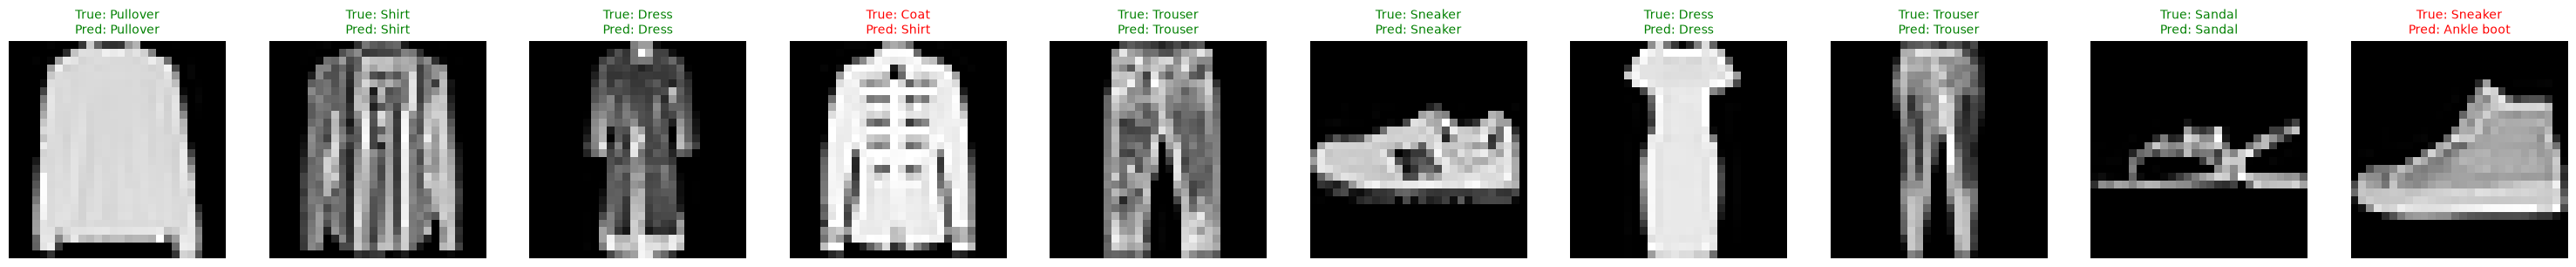

Image 5929: true label = Pullover, predicted label = Pullover
Image 7194: true label = Shirt, predicted label = Shirt
Image 311: true label = Dress, predicted label = Dress
Image 396: true label = Coat, predicted label = Shirt
Image 8908: true label = Trouser, predicted label = Trouser
Image 3788: true label = Sneaker, predicted label = Sneaker
Image 1393: true label = Dress, predicted label = Dress
Image 9356: true label = Trouser, predicted label = Trouser
Image 1829: true label = Sandal, predicted label = Sandal
Image 6129: true label = Sneaker, predicted label = Ankle boot


In [17]:
classifier.predict_and_show(num_images=10)